Jumlah data awal: 5538
Jumlah data setelah cleaning: 4874
Data train : 3899
Data test  : 975
Model berhasil dilatih

=== HASIL EVALUASI ===
MAE  : 13.2003
RMSE : 16.8179
R²   : 82.75%

Intercept:
-1.094754893157429

Koefisien:
pm10: 0.471016
so2: 0.462222
co: -0.122609
o3: 0.728198
no2: 0.500774


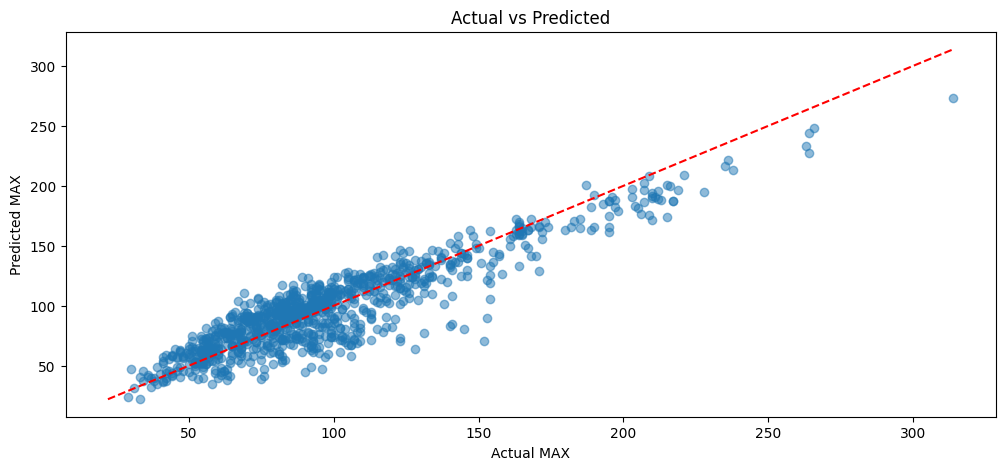

Model tersimpan: model_aqi.pkl


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("ispu_dki_all.csv")

print("Jumlah data awal:", len(df))

df = df.drop(columns=['pm25'])

df = df[df['categori'] != 'TIDAK ADA DATA']

df = df.dropna()

print("Jumlah data setelah cleaning:", len(df))

X = df[
    [
        'pm10',
        'so2',
        'co',
        'o3',
        'no2'
    ]
]

y = df['max']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data train :", len(X_train))
print("Data test  :", len(X_test))


model = LinearRegression()

model.fit(X_train, y_train)

print("Model berhasil dilatih")


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("\n=== HASIL EVALUASI ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2*100:.2f}%")

print("\nIntercept:")
print(model.intercept_)

print("\nKoefisien:")

for nama, coef in zip(X.columns, model.coef_):
    print(f"{nama}: {coef:.6f}")

plt.figure(figsize=(12,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

plt.title("Actual vs Predicted")
plt.xlabel("Actual MAX")
plt.ylabel("Predicted MAX")

plt.show()

import joblib

joblib.dump(
    model,
    "model_aqi.pkl"
)

print("Model tersimpan: model_aqi.pkl")

In [3]:
import joblib
import m2cgen as m2c

print("Load model...")

model = joblib.load(
    "model_aqi.pkl"
)

print("Export ke C++...")

code_cpp = m2c.export_to_c(model)

file_content = f"""
#ifndef MODEL_REGRESI_H
#define MODEL_REGRESI_H

/*
Input:
input[0] = pm10
input[1] = so2
input[2] = co
input[3] = o3
input[4] = no2
*/

{code_cpp}

#endif
"""

with open(
    "model_regresi.h",
    "w"
) as f:

    f.write(file_content)

print("Berhasil membuat model_regresi.h")

Load model...
Export ke C++...
Berhasil membuat model_regresi.h


In [ ]:
import os

print("Original Model Size (MB):", os.path.getsize("model_regresi.h") / 1e6)

Original Model Size (MB): 0.000394
